Milestone 2: Visual Exploration and Flight Delay Trend Analysis

Dataset Description

The airline dataset contains information about flight departures, airports, routes, and flight status. It includes details such as departure date, time, route, month, and delay status. This dataset is used to analyze flight distribution patterns and identify delay trends using different visualizations.

Import Required Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

Load Dataset

In [5]:
file_path = r"C:\Users\Ankita\airfly_insights_dashboard\data\raw\Airline_Dataset_Updated_Final.xlsx"

df = pd.read_excel(file_path)

print("Dataset Loaded Successfully ✅")

Dataset Loaded Successfully ✅


In [17]:
df.head()

,Age,Airport Continent,Airport Country Code,Airport Name,Arrival Airport,Continents,Country Name,Departure Date,First Name,Flight Status,...,Nationality,Passenger ID,Pilot Name,Day of Departure,Time of Departure,Year,Month,Route,IsDelayed,IsCancelled
0,62,NAM,US,Coldfoot Airport,CXF,North America,United States,2022-06-28,Edithe,On Time,...,Japan,ABVWIg,Fransisco Hazeldine,Tuesday,18:46,2022.0,June,Coldfoot Airport - CXF,0,0
1,62,NAM,CA,Kugluktuk Airport,YCO,North America,Canada,2022-12-26,Elwood,On Time,...,Nicaragua,jkXXAX,Marla Parsonage,Monday,14:20,2022.0,December,Kugluktuk Airport - YCO,0,0
2,67,EU,FR,Grenoble-Isère Airport,GNB,Europe,France,2022-01-18,Darby,On Time,...,Russia,CdUz2g,Rhonda Amber,Tuesday,21:34,2022.0,January,Grenoble-Isère Airport - GNB,0,0
3,71,NAM,CA,Ottawa / Gatineau Airport,YND,North America,Canada,2022-09-16,Dominica,Delayed,...,China,BRS38V,Kacie Commucci,Friday,18:50,2022.0,September,Ottawa / Gatineau Airport - YND,1,0
4,21,NAM,US,Gillespie Field,SEE,North America,United States,2022-02-25,Bay,On Time,...,China,9kvTLo,Ebonee Tree,Friday,18:15,2022.0,February,Gillespie Field - SEE,0,0


In [18]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98619 entries, 0 to 98618
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Age                   98619 non-null  int64         
 1   Airport Continent     98619 non-null  object        
 2   Airport Country Code  98619 non-null  object        
 3   Airport Name          98619 non-null  object        
 4   Arrival Airport       98619 non-null  object        
 5   Continents            98619 non-null  object        
 6   Country Name          98619 non-null  object        
 7   Departure Date        59658 non-null  datetime64[ns]
 8   First Name            98619 non-null  object        
 9   Flight Status         98619 non-null  object        
 10  Gender                98619 non-null  object        
 11  Last Name             98619 non-null  object        
 12  Nationality           98619 non-null  object        
 13  Passenger ID    

Index(['Age', 'Airport Continent', 'Airport Country Code', 'Airport Name',
       'Arrival Airport', 'Continents', 'Country Name', 'Departure Date',
       'First Name', 'Flight Status', 'Gender', 'Last Name', 'Nationality',
       'Passenger ID', 'Pilot Name', 'Day of Departure', 'Time of Departure',
       'Year', 'Month', 'Route', 'IsDelayed', 'IsCancelled'],
      dtype='object')


Univariate & Bivariate Visualization

Visualization 1 — Top Airlines / Airports

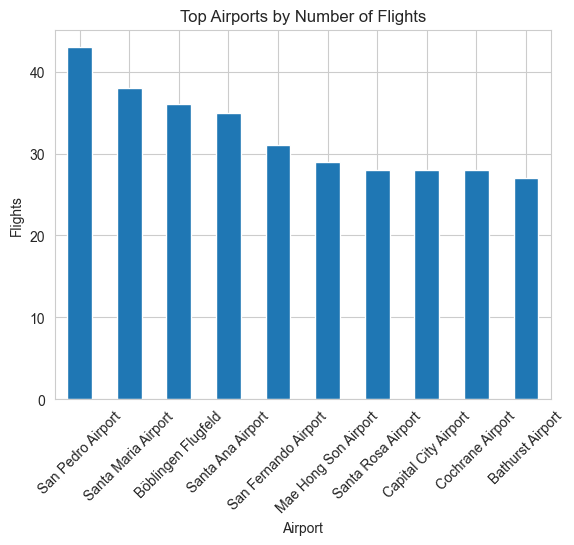

In [19]:
top_airports = df['Airport Name'].value_counts().head(10)

plt.figure()
top_airports.plot(kind='bar')
plt.title("Top Airports by Number of Flights")
plt.xlabel("Airport")
plt.ylabel("Flights")
plt.xticks(rotation=45)
plt.show()

Visualization 2 — Busiest Months

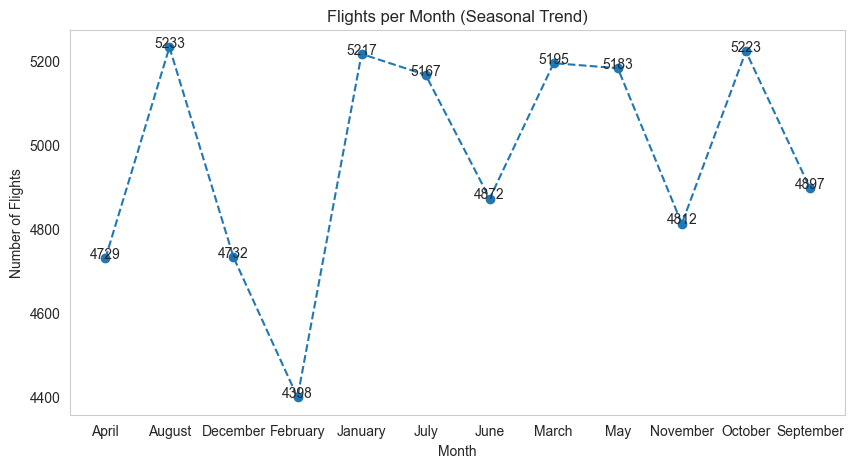

In [6]:
monthly = df['Month'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly.values, marker='o', linestyle='--')

# Add labels
for x, y in zip(monthly.index, monthly.values):
    plt.text(x, y, str(y), ha='center')

plt.title("Flights per Month (Seasonal Trend)")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.grid()
plt.show()

Visualization 3 — Flights by Day

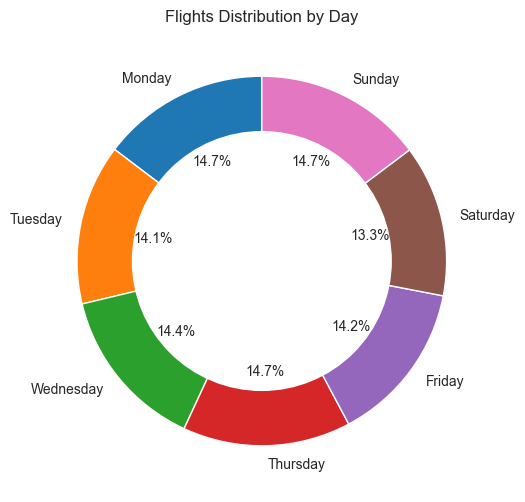

In [8]:
plt.figure(figsize=(6,6))
plt.pie(day_counts, labels=day_counts.index, autopct='%1.1f%%', startangle=90)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Flights Distribution by Day")
plt.show()

Visualization 4 — Departure Time Distribution

C:\Users\Ankita\AppData\Local\Temp\ipykernel_10524\2602433037.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time of Departure'] = pd.to_datetime(df['Time of Departure'])


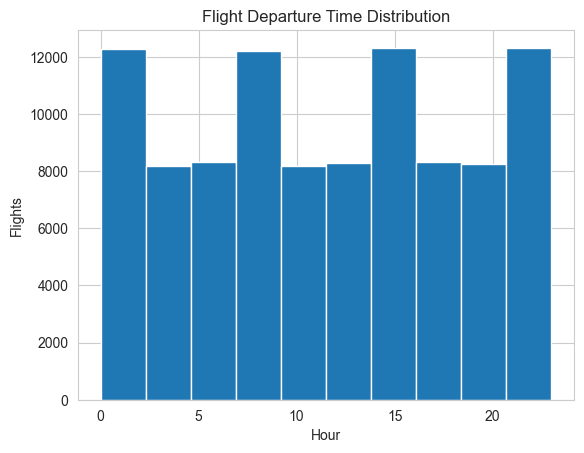

In [10]:
df['Time of Departure'] = pd.to_datetime(df['Time of Departure'])

plt.hist(df['Time of Departure'].dt.hour)
plt.title("Flight Departure Time Distribution")
plt.xlabel("Hour")
plt.ylabel("Flights")
plt.show()

Visualization 5 — Route Analysis


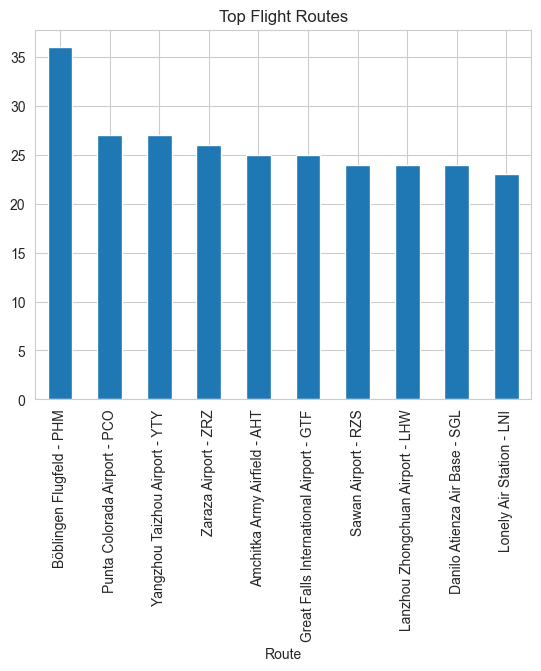

In [24]:
routes = df['Route'].value_counts().head(10)

routes.plot(kind='bar')
plt.title("Top Flight Routes")
plt.show()

Week 4 Delay Analysis

Delayed vs On-Time Flights

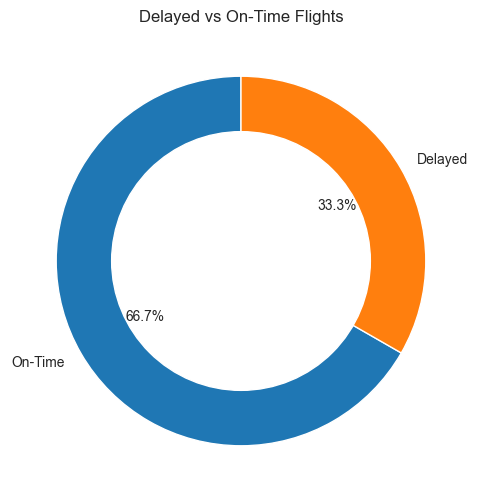

In [11]:
delay_counts = df['IsDelayed'].value_counts()

labels = ['On-Time', 'Delayed']

plt.figure(figsize=(6,6))
plt.pie(delay_counts, labels=labels, autopct='%1.1f%%', startangle=90)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Delayed vs On-Time Flights")
plt.show()

Delay by Month

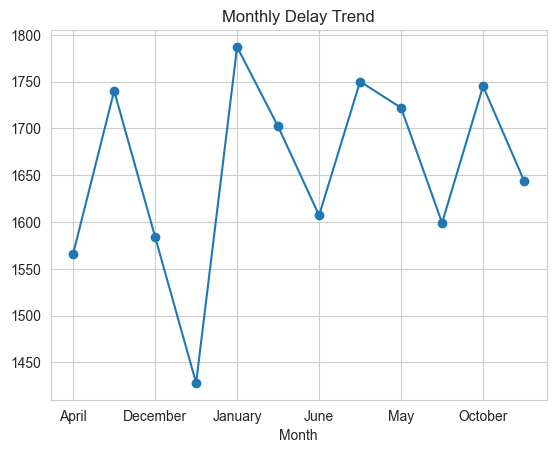

In [26]:
delay_month = df.groupby('Month')['IsDelayed'].sum()

delay_month.plot(kind='line', marker='o')
plt.title("Monthly Delay Trend")
plt.show()

Airport Delay Comparison


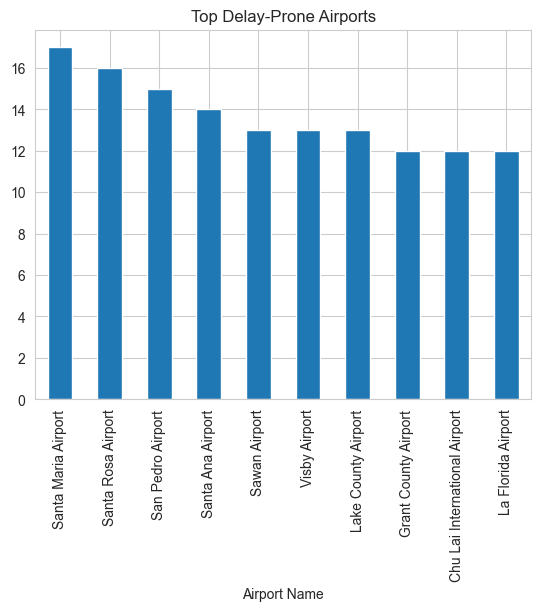

In [27]:
airport_delay = df.groupby('Airport Name')['IsDelayed'].sum().sort_values(ascending=False).head(10)

airport_delay.plot(kind='bar')
plt.title("Top Delay-Prone Airports")
plt.show()

Observation

Observation:
Most delays occur during peak travel months indicating traffic congestion.

In [2]:
print("Milestone 2 Completed ✅")

Milestone 2 Completed ✅
